# RNN – A to Z Alphabet Sequence Prediction
Same structure as the numeric RNN (1 to 100),
but uses A–Z alphabet instead of numbers.

In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt


In [2]:
# Create sequence: A to Z  (like range(1, 101) in numeric version)
sequence = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
print(sequence)


['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [3]:
# Map each letter to an integer index  (A=0, B=1, ... Z=25)
char_to_idx = {c: i for i, c in enumerate(sequence)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

seq_nums = np.array([char_to_idx[c] for c in sequence])
print(seq_nums)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [4]:
# Define window size: 3 inputs → 1 output
window_size = 3
# X = inputs / questions
# y = correct answers
X = []
y = []


In [5]:
# Create input-output pairs
for i in range(len(seq_nums) - window_size):
    X.append(seq_nums[i : i + window_size])
    y.append(seq_nums[i + window_size])

print('First 5 input examples:')
print([[idx_to_char[v] for v in row] for row in X[:5]])
print('First 5 answers:')
print([idx_to_char[v] for v in y[:5]])


First 5 input examples:
[['A', 'B', 'C'], ['B', 'C', 'D'], ['C', 'D', 'E'], ['D', 'E', 'F'], ['E', 'F', 'G']]
First 5 answers:
['D', 'E', 'F', 'G', 'H']


In [6]:
X = np.array(X)
y = np.array(y)

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (23, 3)
y shape: (23,)


In [7]:
# Reshape X to: samples, timesteps, features
X = X.reshape((X.shape[0], X.shape[1], 1))
print('New X shape:', X.shape)


New X shape: (23, 3, 1)


In [8]:
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(window_size, 1)))
model.add(Dense(26, activation='softmax'))  # 26 outputs, one per letter

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 26)             │         1,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,926 (15.34 KB)

 Trainable params: 3,926 (15.34 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [10]:
model.fit(X, y, epochs=500, verbose=2)
print("Training complete.")


Epoch 1/500
1/1 - 2s - 2s/step - accuracy: 0.0000e+00 - loss: 6.4920
Epoch 2/500
1/1 - 0s - 49ms/step - accuracy: 0.0000e+00 - loss: 6.1968
Epoch 3/500
1/1 - 0s - 48ms/step - accuracy: 0.0000e+00 - loss: 5.9218
Epoch 4/500
1/1 - 0s - 48ms/step - accuracy: 0.0435 - loss: 5.6711
Epoch 5/500
1/1 - 0s - 46ms/step - accuracy: 0.0435 - loss: 5.4452
Epoch 6/500
1/1 - 0s - 44ms/step - accuracy: 0.0435 - loss: 5.2452
Epoch 7/500
1/1 - 0s - 53ms/step - accuracy: 0.0435 - loss: 5.0651
Epoch 8/500
1/1 - 0s - 46ms/step - accuracy: 0.0435 - loss: 4.9049
Epoch 9/500
1/1 - 0s - 44ms/step - accuracy: 0.0435 - loss: 4.7587
Epoch 10/500
1/1 - 0s - 47ms/step - accuracy: 0.0435 - loss: 4.6228
Epoch 11/500
1/1 - 0s - 60ms/step - accuracy: 0.0435 - loss: 4.4940
Epoch 12/500
1/1 - 0s - 51ms/step - accuracy: 0.0435 - loss: 4.3750
Epoch 13/500
1/1 - 0s - 45ms/step - accuracy: 0.0435 - loss: 4.2653
Epoch 14/500
1/1 - 0s - 46ms/step - accuracy: 0.0435 - loss: 4.1647
Epoch 15/500
1/1 - 0s - 50ms/step - accuracy: 0

In [11]:
# Predict the letter after A, B, C  →  should be D
test_input = np.array([char_to_idx['A'], char_to_idx['B'], char_to_idx['C']])
# RNN expects: samples, timesteps, features
test_input = test_input.reshape((1, window_size, 1))

pred_probs = model.predict(test_input, verbose=0)
pred_idx   = np.argmax(pred_probs)
print(f'Predicted next letter: {idx_to_char[pred_idx]}')


Predicted next letter: D


In [12]:
predictions = model.predict(X, verbose=0)
pred_indices = np.argmax(predictions, axis=1)


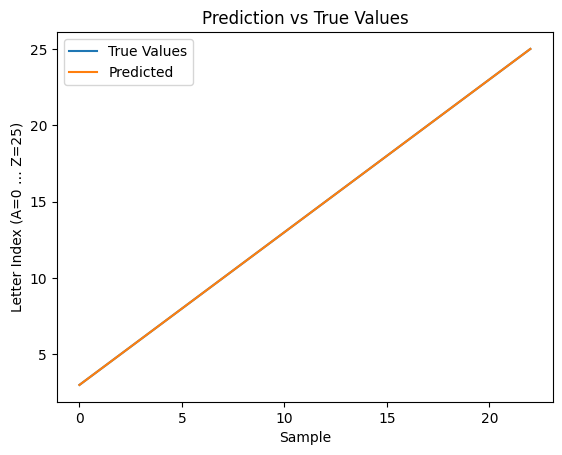

In [13]:
plt.plot(y,            label='True Values')
plt.plot(pred_indices, label='Predicted')
plt.legend()
plt.title('Prediction vs True Values')
plt.xlabel('Sample')
plt.ylabel('Letter Index (A=0 … Z=25)')
plt.show()
